# Forecasting 2017 Video Game Sales

As an analyst for global online video game retailer Ice, I will look at open source data on user and expert reviews, genres, platforms, and historical game sales to identify patterns that determine the success of games and spot potential big winners to inform 2017 advertising strategy. 

We will examine data in one table to compare sales across platforms, regions, and genres, understand how sales are affected by reviews and ratings, and test two hypotheses:

* Average user ratings of the Xbox One and PC platforms are the same
* Average user ratings for the Action and Sports genres are different

## Open the data file and study the general information

In step 1, we take a first look at the dataset to understand data types and identify columns with missing data. We'll print a sample of the data, call info, and check for duplicate rows.

We begin by loading all the libraries we will need for the analysis.

In [1]:
# Loading all the libraries
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats as st
import numpy as np

Then we load the dataset and save the result.

In [2]:
# Load the data file into a DataFrame
game_data=pd.read_csv('/datasets/games.csv')

Now we can call info and print a sample of the data to see what it looks like and whether any columns are formatted incorrectly or missing values.

In [3]:
# Print the general/summary information about the DataFrame

game_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


Calling info immediately reveals two issues. First, the column names need to be converted to lowercase. Second, six columns have missing values: Name, Year_of_Release, Genre, Critic_Score, User_Score, and Rating. 

Printing a few rows of the dataframe will now help us determine if we need to change the data types in any columns.

In [4]:
# Print a sample of the data

print(game_data.head())

                       Name Platform  Year_of_Release         Genre  NA_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29.08   
2            Mario Kart Wii      Wii           2008.0        Racing     15.68   
3         Wii Sports Resort      Wii           2009.0        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing     11.27   

   EU_sales  JP_sales  Other_sales  Critic_Score User_Score Rating  
0     28.96      3.77         8.45          76.0          8      E  
1      3.58      6.81         0.77           NaN        NaN    NaN  
2     12.76      3.79         3.29          82.0        8.3      E  
3     10.93      3.28         2.95          80.0          8      E  
4      8.89     10.22         1.00           NaN        NaN    NaN  


Based on this sample, it looks like Year_of_Release should be changed to an integer and User_Score should be changed to a float.

We can also check for any duplicates.

In [5]:
# check for duplicate rows
print(game_data.duplicated().sum())

0


Looks like no duplicate rows.

## Prepare the data

In step 2, we clean up the data and get it in shape for analysis by:

* Converting all column names to lowercase
* Dealing with missing values
* Converting datatypes of columns (as necessary)
* Adding any additional columns that will be useful for analysis


We start by converting all the column names to lowercase.

In [6]:
# Convert all column names to lowercase
game_data.columns=game_data.columns.str.lower()
# print to confirm
print(game_data.head())

                       name platform  year_of_release         genre  na_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29.08   
2            Mario Kart Wii      Wii           2008.0        Racing     15.68   
3         Wii Sports Resort      Wii           2009.0        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing     11.27   

   eu_sales  jp_sales  other_sales  critic_score user_score rating  
0     28.96      3.77         8.45          76.0          8      E  
1      3.58      6.81         0.77           NaN        NaN    NaN  
2     12.76      3.79         3.29          82.0        8.3      E  
3     10.93      3.28         2.95          80.0          8      E  
4      8.89     10.22         1.00           NaN        NaN    NaN  


Next, we dig into the missing values. We already know from calling info before that there are different amounts of missing values in the different columns, but printing a sample of the rows with missing values might give us more insight on any patterns.

In [7]:
print(game_data[game_data.isna().any(axis=1)].sample(15, random_state=1))

                                                    name platform  \
11893                WRC 2: FIA World Rally Championship     X360   
10403                             Skylanders Imaginators      PS3   
11466            My English Coach: Para Hispanoparlantes       DS   
15009             Shinseiki Evangelion: Battle Orchestra      PS2   
2681                        The Walking Dead: Season One      PS3   
11304                          Famicom Mini: Mario Bros.      GBA   
12980                                   Minna no Ennichi      3DS   
14791                         Gintama: Banji Oku Chuubu!      Wii   
6417           Sesame Street: Cookie's Counting Carnival       DS   
9691   Hisshou Pachinko*Pachi-Slot Kouryaku Series Vo...      PS2   
9857                         DreamWorks Super Star Kartz      3DS   
14213                                          Gacharoku      PS2   
14120                         Black Stone: Magic & Steel       XB   
15874                     Yoake Yo

There isn't an obvious pattern to the missing values in the sample, so my assumption is that the missing values are a result of merging different datasets. Perhaps the different datasets didn't include all the same games, and the values in the name column also suggest possible data loss from inconsistent naming. For example, line 11893 above uses a number for the game version (2), while line 4879 uses a roman numeral (IV).

To deal with the missing values, we start with the name and genre columns because they are both missing only two values and they might be in the same row.

In [8]:
# print rows where name column is missing values
print(game_data[game_data['name'].isna()])

      name platform  year_of_release genre  na_sales  eu_sales  jp_sales  \
659    NaN      GEN           1993.0   NaN      1.78      0.53      0.00   
14244  NaN      GEN           1993.0   NaN      0.00      0.00      0.03   

       other_sales  critic_score user_score rating  
659           0.08           NaN        NaN    NaN  
14244         0.00           NaN        NaN    NaN  


We confirm that two 1993 games from the GEN platform are both missing name and genre values. It is unclear why these values are missing, and we can't infer the values from the information we have. Since 2 out of 16,715 rows is such a miniscule amount of data (.01%), we can just drop these rows without materially impacting our analysis.

In [9]:
# Drop rows missing the game name
game_data=game_data.dropna(subset=['name'])
# Confirm rows are removed
game_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16713 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16713 non-null  object 
 2   year_of_release  16444 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.5+ MB


This leaves us with four columns that still have missing values. 

For both the critic_score and user_score columns, we can't infer the missing values from the information in other columns or fill them in with averages because these values are based on subjective scores that are unique to each game. It is therefore best to leave the missing values in these columns as is, or the analysis will be skewed.

For the rating column, another reason for missing values could be that the ESRB was not created until 1994, so any games released before then are unrated. To dig into this, we can look at how many pre-1994 games are included in the dataset and confirm they are all missing ratings.

In [10]:
# Print the number of pre-1994 games in the dataset
print('Pre-1994 games:', game_data.loc[game_data['year_of_release'] < 1994, 'rating'].isna().count())
# Print the number of pre-1994 games in the dataset missing ratings
print('Pre-1994 games missing a rating:', game_data.loc[game_data['year_of_release'] < 1994, 'rating'].isna().sum())
# Print a sample of pre-1994 game ratings
print(game_data.loc[game_data['year_of_release'] < 1994, 'rating'])

Pre-1994 games: 365
Pre-1994 games missing a rating: 361
1         NaN
5         NaN
9         NaN
18        NaN
21        NaN
         ... 
14610       M
14621    E10+
15692     NaN
15957     NaN
16207     NaN
Name: rating, Length: 365, dtype: object


Strangely, four pre-1994 games in this dataset have an ESRB rating. It is particularly odd that one of these games has an E10+ rating (Everyone 10 and up), as this rating was not introduced until 2005! These ratings might have been added by whomever compiled the dataset, and raise a bit of a data quality red flag for this entire column. We can fill in 'not rated' for all pre-1994 games (overwriting the four incorrectly rated games). 

In [11]:
# Fill missing ratings for games released before 1994 with "not rated"
game_data.loc[game_data['year_of_release'] < 1994.0, 'rating'] ='not rated'

This still leaves us with a lot of missing ratings. We can't infer the ratings from the data we have, since ratings can differ by platform and release version for the same game. However, we know we want to do some analysis on ratings and regional sales later on, so let's see whether there is a pattern to the missing ratings by region that will introduce bias in our analysis. 

We know that the ESRB rating system is a North American system, so it's possible that games which only sold outside of North America are missing ratings.

In [12]:
# Create filtered dataframes for games that only had sales in certain regions
sales_na_only = game_data[(game_data['eu_sales'] == 0) & (game_data['jp_sales'] == 0) &(game_data['na_sales'] > 0)]
sales_eu_only = game_data[(game_data['na_sales'] == 0) & (game_data['jp_sales'] == 0) &(game_data['eu_sales'] > 0)]
sales_jp_only = game_data[(game_data['na_sales'] == 0) & (game_data['eu_sales'] == 0) &(game_data['jp_sales'] > 0)]
sales_outside_na_only = game_data[(game_data['na_sales'] == 0) & (game_data['eu_sales'] > 0) &(game_data['jp_sales'] > 0)]
sales_in_na = game_data[(game_data['na_sales'] > 0)]

# Count games with a missing rating in each dataframe
missing_count_jp = sales_jp_only['rating'].isna().sum()
missing_count_eu = sales_eu_only['rating'].isna().sum()
missing_count_na = sales_na_only['rating'].isna().sum()
missing_count_outside_na = sales_outside_na_only['rating'].isna().sum()
missing_count_na_ref = sales_in_na['rating'].isna().sum()

# Count number of games in each dataframe
total_count_jp = sales_jp_only.shape[0]
total_count_eu = sales_eu_only.shape[0]
total_count_na = sales_na_only.shape[0]
total_count_outside_na = sales_outside_na_only.shape[0]
total_count_in_na = sales_in_na.shape[0]

# Calculate percentages of missing ratings for each
missing_pct_jp = (missing_count_jp / total_count_jp) * 100
missing_pct_eu = (missing_count_eu / total_count_eu) * 100
missing_pct_na = (missing_count_na / total_count_na) * 100
missing_pct_outside_na = (missing_count_outside_na / total_count_outside_na) * 100
missing_pct_na_ref = (missing_count_na_ref / total_count_in_na) * 100

# Print results, rounded to 2 decimal places
print(f"Percentage of JP-only games missing rating: {missing_pct_jp:.2f}%")
print(f"Percentage of EU-only games missing rating: {missing_pct_eu:.2f}%")
print(f"Percentage of Outside-NA-only games missing rating: {missing_pct_outside_na:.2f}%")
print(f"Percentage of games with NA sales missing rating: {missing_pct_na_ref:.2f}%")
print(f"Percentage of NA-only games missing rating: {missing_pct_na:.2f}%")

Percentage of JP-only games missing rating: 92.73%
Percentage of EU-only games missing rating: 41.47%
Percentage of Outside-NA-only games missing rating: 45.35%
Percentage of games with NA sales missing rating: 22.84%
Percentage of NA-only games missing rating: 18.31%


Even among the games that sold in North America (or only sold in North America), around 20% are missing ratings, which tells us that we simply have a fair amount of missing data in the ratings column across the board. 

However, we can also see that almost half of the games that didn't do any sales in North America are missing ratings, and almost all the games that only sold in Japan are missing ratings. We'll change these missing values to "unknown" so we can see them in our analysis later on.

In [13]:
game_data['rating'] = game_data['rating'].fillna('unknown')

This leaves us with the missing values in the year_of_release column. For this column, the platform information can help impute the missing values because each platform only releases games within a certain timeframe (e.g., the Wii was released in 2006 so any Wii games would need to have a post-2006 release date). To figure out filling in these missing values, we can start by taking a preliminary look at the distribution of platform releases by year. 

In [14]:
# Create a pivot table showing the count of game releases per platform per year and save the result
yearly_platform_distribution=game_data.pivot_table(index='year_of_release', columns='platform', values='name', aggfunc='count')

# Print result
print (yearly_platform_distribution)


platform         2600  3DO    3DS    DC     DS    GB    GBA     GC   GEN   GG  \
year_of_release                                                                 
1980.0            9.0  NaN    NaN   NaN    NaN   NaN    NaN    NaN   NaN  NaN   
1981.0           46.0  NaN    NaN   NaN    NaN   NaN    NaN    NaN   NaN  NaN   
1982.0           36.0  NaN    NaN   NaN    NaN   NaN    NaN    NaN   NaN  NaN   
1983.0           11.0  NaN    NaN   NaN    NaN   NaN    NaN    NaN   NaN  NaN   
1984.0            1.0  NaN    NaN   NaN    NaN   NaN    NaN    NaN   NaN  NaN   
1985.0            1.0  NaN    NaN   NaN    1.0   NaN    NaN    NaN   NaN  NaN   
1986.0            2.0  NaN    NaN   NaN    NaN   NaN    NaN    NaN   NaN  NaN   
1987.0            6.0  NaN    NaN   NaN    NaN   NaN    NaN    NaN   NaN  NaN   
1988.0            2.0  NaN    NaN   NaN    NaN   1.0    NaN    NaN   NaN  NaN   
1989.0            2.0  NaN    NaN   NaN    NaN  10.0    NaN    NaN   NaN  NaN   
1990.0            NaN  NaN  

Based on the sample above, each platform's distribution is constrained to a subset of years but the distribution type varies by platform. Some are close to a normal distribution (XB), some are skewed (2600), and some are bimodal (GB). To determine the best method to fill in the missing values, we can also look at the count of missing values across platforms.

In [15]:
# Count missing years by platform
missing_years=game_data['year_of_release'].isna().groupby(game_data['platform']).sum()
# Print the result
print(missing_years)

platform
2600    17
3DO      0
3DS      8
DC       0
DS      30
GB       1
GBA     11
GC      14
GEN      0
GG       0
N64      3
NES      0
NG       0
PC      17
PCFX     0
PS       7
PS2     34
PS3     25
PS4      0
PSP     16
PSV      1
SAT      0
SCD      0
SNES     0
TG16     0
WS       0
Wii     34
WiiU     0
X360    30
XB      21
XOne     0
Name: year_of_release, dtype: int64


It looks like the missing values are fairly spread out over the different platforms, and the platforms with missing values are spread out over different time periods. Based on this information, I think the best approach is to fill in the missing values using random sampling by platform to preserve each platform's existing distribution. This won't be very accurate with a high ratio of missing to existing values, but I can tell from the pivot table above that this will only be an issue for now-defunct platforms that I'm not going to focus on in my model anyway. 

In [16]:
# Define a function to fill in the missing years using random sampling based on each platform's distribution
def fill_missing_years(df, platform_info='platform', year_info='year_of_release'):
    df_filled = df.copy()
    
    # Pull existing years for each platform
    for platform in df_filled[platform_info].unique():
        existing_years = df_filled.loc[df_filled[platform_info] == platform, year_info].dropna()

        # For platforms with existing years, fill missing years using random sampling
        if existing_years.shape[0] > 0:
            missing_years = df_filled[(df_filled[platform_info] == platform) & (df_filled[year_info].isna())].index
            df_filled.loc[missing_years, year_info] = np.random.choice(existing_years, size=len(missing_years), replace=True)
    
    return df_filled

# Run function
game_data = fill_missing_years(game_data)

# Call info
game_data.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 16713 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16713 non-null  object 
 2   year_of_release  16713 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           16713 non-null  object 
dtypes: float64(6), object(5)
memory usage: 2.0+ MB


Now the year_of_release column is all filled in, and we can convert it to an integer.

In [17]:
# Convert year_of_release to an integer
game_data['year_of_release']=game_data['year_of_release'].astype(int)

We also want to convert the user_score column to a float so we can run calculations on user scores. The fact that the column is currently an object datatype means there are probably string values in this column, and printing the unique values will tell us what those are.

In [18]:
print(game_data['user_score'].unique())

['8' nan '8.3' '8.5' '6.6' '8.4' '8.6' '7.7' '6.3' '7.4' '8.2' '9' '7.9'
 '8.1' '8.7' '7.1' '3.4' '5.3' '4.8' '3.2' '8.9' '6.4' '7.8' '7.5' '2.6'
 '7.2' '9.2' '7' '7.3' '4.3' '7.6' '5.7' '5' '9.1' '6.5' 'tbd' '8.8' '6.9'
 '9.4' '6.8' '6.1' '6.7' '5.4' '4' '4.9' '4.5' '9.3' '6.2' '4.2' '6' '3.7'
 '4.1' '5.8' '5.6' '5.5' '4.4' '4.6' '5.9' '3.9' '3.1' '2.9' '5.2' '3.3'
 '4.7' '5.1' '3.5' '2.5' '1.9' '3' '2.7' '2.2' '2' '9.5' '2.1' '3.6' '2.8'
 '1.8' '3.8' '0' '1.6' '9.6' '2.4' '1.7' '1.1' '0.3' '1.5' '0.7' '1.2'
 '2.3' '0.5' '1.3' '0.2' '0.6' '1.4' '0.9' '1' '9.7']


This shows us that some user scores are filled in as "tbd" or "to be determined". It's worth checking if "tbd" appears in any other object column.

In [19]:
# Define the function to check occurences of tbd in other object columns
for col in ['name', 'platform', 'genre', 'rating']:
    # Convert all text to lowercase to catch any instances regardless of case
    count = game_data[col].astype(str).str.lower().eq('tbd').sum()
    # Print result for each column
    print(f"Count of 'tbd' in column '{col}': {count}")

Count of 'tbd' in column 'name': 0
Count of 'tbd' in column 'platform': 0
Count of 'tbd' in column 'genre': 0
Count of 'tbd' in column 'rating': 0


Now that we know this issue is just in the user_score column, I want to see the pattern of "tbd" values and years --if it's just appearing in one or a few most recent years, replacing it might skew our analysis.

In [20]:
# Count tdb scores by year
tbd_score_years=game_data[game_data['user_score']=='tbd'].groupby('year_of_release')['user_score'].count()
# Print the result
print(tbd_score_years)

year_of_release
1997      1
1998      1
1999      8
2000     43
2001     83
2002    196
2003     98
2004    111
2005    123
2006    126
2007    198
2008    333
2009    411
2010    335
2011    220
2012     27
2013     15
2014     23
2015     38
2016     34
Name: user_score, dtype: int64


Look like there are tbd values in every year. We don't know the source of the user_score data, and without an explanation or discernible pattern the most likely explanation is that 'tbd' was being used as a placeholder for missing values. Based on that assumption we can convert the 'tbd' values to NaN. 

In [21]:
# Convert tbd values to NaN values

game_data.replace('tbd', np.nan, inplace=True)

Now we should be able to convert the user_score column to a float datatype.

In [22]:
# Convert user_score to float
game_data['user_score']=game_data['user_score'].astype(float)

# Call info
game_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16713 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16713 non-null  object 
 2   year_of_release  16713 non-null  int64  
 3   genre            16713 non-null  object 
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           16713 non-null  object 
dtypes: float64(6), int64(1), object(4)
memory usage: 2.0+ MB


All columns are now the correct datatype, and we've handled all missing values. For the final preparation step, we'll add a total_sales column showing the sum of sales in all regions for each game.

In [23]:
# Define a function to calculate total sales based on the values in each regional sales column

def total_sales(row):
    total_sales_value=row['na_sales']+row['eu_sales']+row['jp_sales']+row['other_sales']
    return total_sales_value

# apply function to the game_data table to create a column showing the total sales for each game
game_data['total_sales']=game_data.apply(total_sales, axis=1)
# print the result
print(game_data.head())

                       name platform  year_of_release         genre  na_sales  \
0                Wii Sports      Wii             2006        Sports     41.36   
1         Super Mario Bros.      NES             1985      Platform     29.08   
2            Mario Kart Wii      Wii             2008        Racing     15.68   
3         Wii Sports Resort      Wii             2009        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB             1996  Role-Playing     11.27   

   eu_sales  jp_sales  other_sales  critic_score  user_score     rating  \
0     28.96      3.77         8.45          76.0         8.0          E   
1      3.58      6.81         0.77           NaN         NaN  not rated   
2     12.76      3.79         3.29          82.0         8.3          E   
3     10.93      3.28         2.95          80.0         8.0          E   
4      8.89     10.22         1.00           NaN         NaN    unknown   

   total_sales  
0        82.54  
1        40.24  
2        35

Now our dataset is ready for analysis!

## Analyze the data


In step 3, we start analyzing our data and exploring patterns in game releases and sales across time and platforms. This includes identifying the most active and relevant years for analysis, examining how sales varied across platforms and genres, and pinpointing platforms that have risen or declined in popularity. I determine which time period offers the most meaningful data for modeling future trends, specifically for 2017, and narrow the dataset accordingly. I also analyze which platforms are currently leading or gaining traction, evaluate differences in sales distributions using boxplots, and explore how critic and user reviews may influence sales.

First, we look at how many games were released in different years and assess whether there is a significant amount of data for each time period.

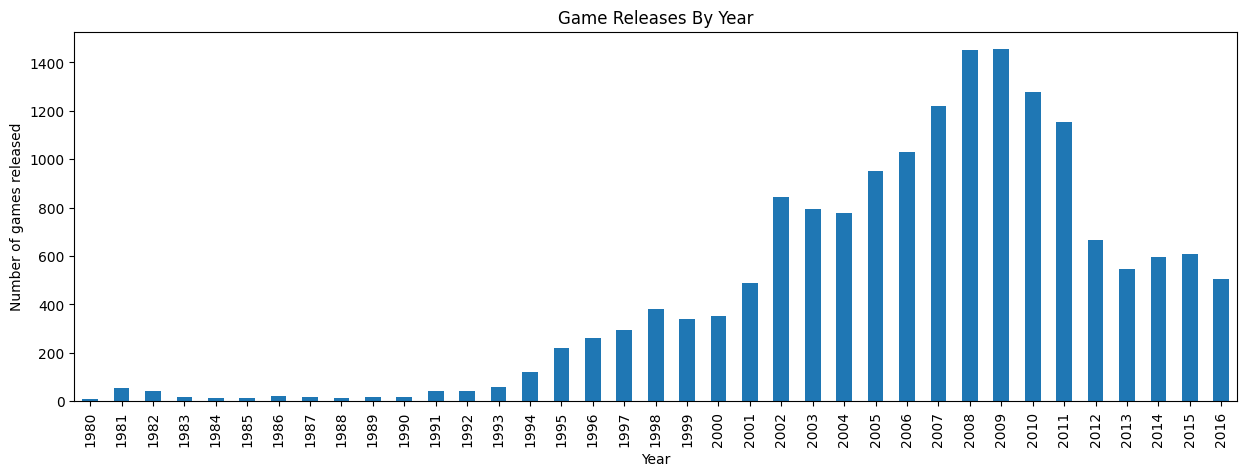

In [24]:
# Count games by year
yearly_games=game_data.groupby('year_of_release').size().reset_index(name='games_count')
# Plot to visualize the distribution
yearly_games_plot=yearly_games.plot(kind='bar', x='year_of_release', y='games_count', legend=False, xlabel='Year', ylabel='Number of games released', title='Game Releases By Year',figsize=(15,4.8))

plt.show()

There are very few game releases in the 80s and not a ton through the 90s either, things pick up a lot more from 2001 onward. This makes sense considering that video game technology has grown and advanced over time.

Next, we look at how sales varied from platform to platform. We filter the top 10 platforms by total sales and build a distribution based on data for each year. 

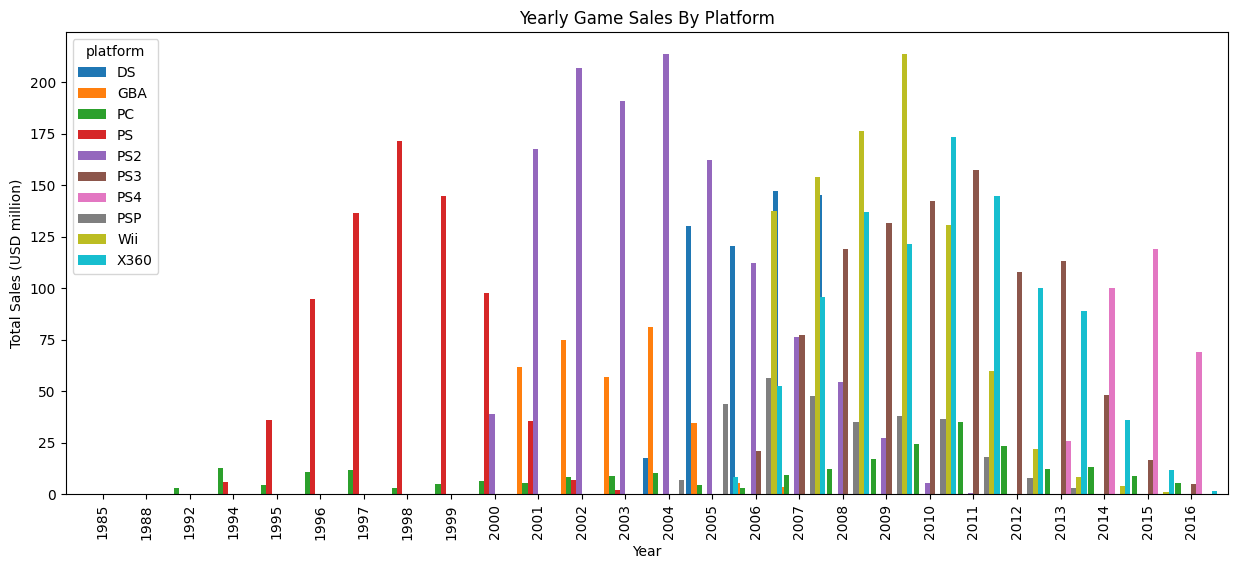

In [25]:
# Calculate total sales by platform
platform_sales = game_data.groupby('platform')['total_sales'].sum()

# ID the top 10 platforms by total sales
top_10_platforms = platform_sales.nlargest(10).index

# Filter game_data to include only these platforms
game_data_top_platforms = game_data[game_data['platform'].isin(top_10_platforms)]

# Create a pivot table with total sales by platform by year
top_platforms_sales=game_data_top_platforms.pivot_table(index='year_of_release', columns='platform', values='total_sales', aggfunc='sum')

# Plot to visualize
top_platforms_sales_plot=top_platforms_sales.plot(kind='bar', xlabel="Year", ylabel='Total Sales (USD million)', title='Yearly Game Sales By Platform',figsize=(15,6), width=1.2)

plt.show()

The plot shows that platforms have a defined lifespan. PS looks like it was very popular in the 90's, but now has zero sales. Typically, it looks like new platforms appear and old ones fade over ~10-year cycles.

Based on this insight, we don't want to include data on old platforms that are now defunct in our 2017 model. We'll focus on the last 3 years of data, and trim any data before 2013.

In [26]:
# Filter game_data to only include data for 2013 onward
modern_game_data=game_data[game_data['year_of_release'] >= 2013]

Now, we can explore which platforms are potentially profitable for the upcoming year. First, we'll look at the platforms with the most sales in the past three years. 

In [27]:
# Calculate total sales by platform and sort from greatest to least
modern_platform_sales = modern_game_data.groupby('platform')['total_sales'].sum()
# Sort from greatest to least
sorted_modern_platforms = modern_platform_sales.sort_values(ascending=False)

# Print result
print(sorted_modern_platforms)

platform
PS4     314.14
PS3     183.11
XOne    159.32
3DS     143.49
X360    138.51
WiiU     64.63
PC       39.65
PSV      33.25
Wii      13.74
PSP       3.50
DS        1.54
Name: total_sales, dtype: float64


We also need to look at which platforms are growing, and which are shrinking. A bar chart will help us see this.

platform           3DS    DS     PC     PS3     PS4   PSP    PSV   Wii   WiiU  \
year_of_release                                                                 
2013             56.57  1.54  12.38  113.25   25.99  3.14  10.59  8.59  21.65   
2014             44.00   NaN  13.28   48.23  100.00  0.24  12.16  3.83  22.03   
2015             27.78   NaN   8.74   16.83  118.90  0.12   6.25  1.14  16.35   
2016             15.14   NaN   5.25    4.80   69.25   NaN   4.25  0.18   4.60   

platform          X360   XOne  
year_of_release                
2013             88.77  18.96  
2014             36.25  54.07  
2015             11.97  60.14  
2016              1.52  26.15  


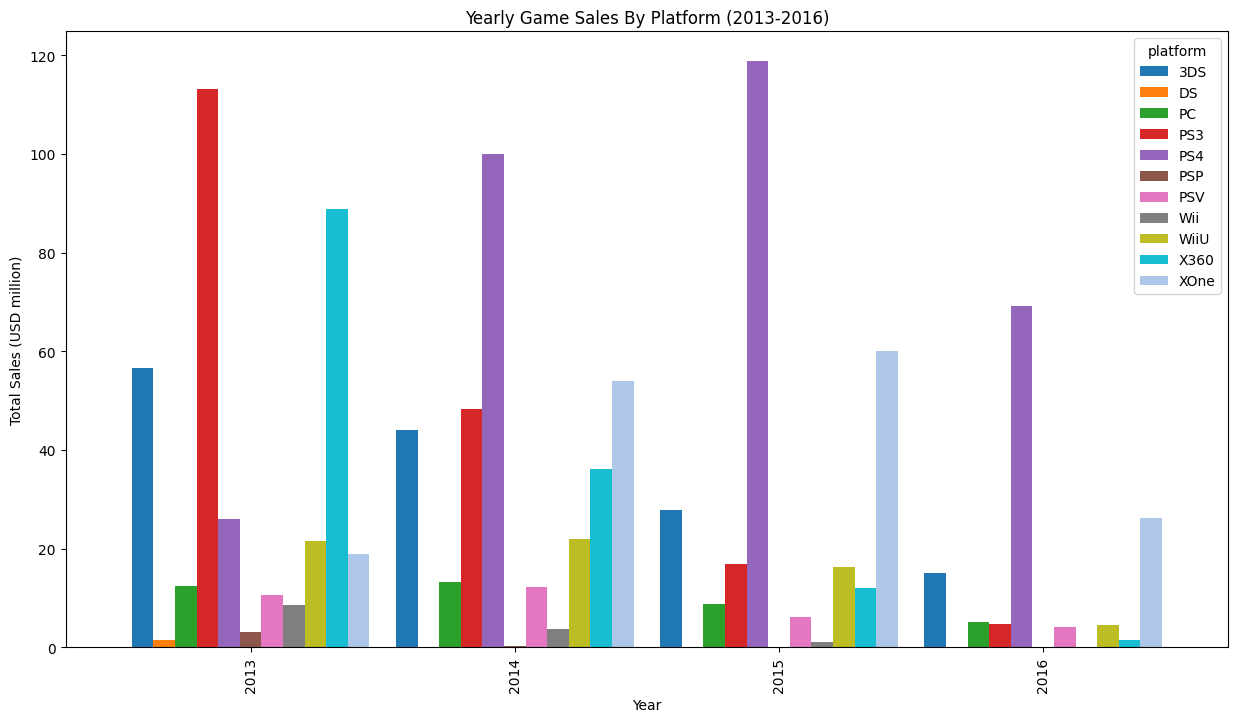

In [28]:
# Create a pivot table with total sales by platform by year
modern_platforms_sales = modern_game_data.pivot_table(index='year_of_release', columns='platform', values='total_sales', aggfunc='sum')
# Print results
print(modern_platforms_sales)

# Plot to visualize
# Ensure distinct colors by defining custom colors
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", "#aec7e8", "#ffbb78","#98df8a", "#ff9896", "#c5b0d5", "#c49c94"]
modern_platforms_sales_plot = modern_platforms_sales.plot(kind='bar', color=colors, xlabel="Year", ylabel='Total Sales (USD million)', title='Yearly Game Sales By Platform (2013-2016)',figsize=(15,8), width=.9)

plt.show()

From this analysis, we can see that PS4, PS3, XOne, 3DS, and X360 were the top sellers in the past few years, but PS3 and X360 sales are shrinking.  Wii, PSP, and DS are also past their prime, and didn't have huge sales to begin with.

PS4 is the clear leader in terms of potentially profitable platforms, and though it doesn't look like sales are on a growth trajectory, it's certainly possible especially considering it is the latest generation Playstation console on the market. 3DS and XOne also should have a few more good sales years, though current data does not suggest that any of these three platforms will grow significantly.

To dig deeper into global sales by platform, we can compare boxplots of global sales of all games by platform.

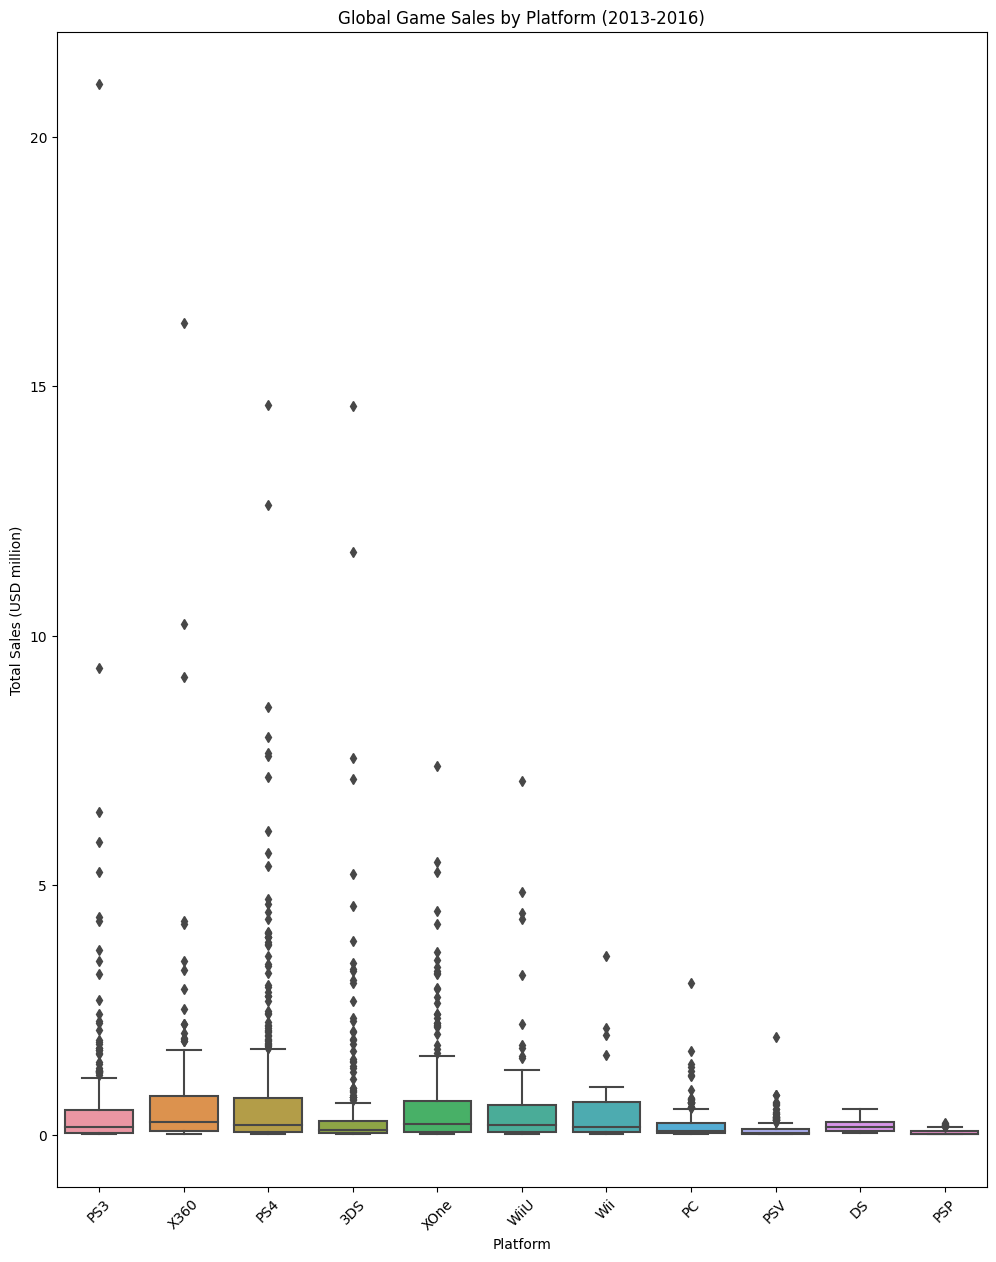

In [29]:
# Set up boxplot figure
plt.figure(figsize=(12, 15))

# Create boxplot
sns.boxplot(data=modern_game_data, x='platform', y='total_sales')

# Set the labels and title
plt.xlabel('Platform')
plt.ylabel('Total Sales (USD million)')
plt.title('Global Game Sales by Platform (2013-2016)')

# Add more Y-axis ticks
plt.yticks(np.arange(0, modern_game_data['total_sales'].max() + 1, step=5))

# Rotate platform names for readability
plt.xticks(rotation=45)  

plt.show()


Looking at these boxplots, some platforms (PS3, X360, PS4, XOne, WiiU, and Wii) have higher median sales, indicating greater success by game on average. These same platforms also have a larger interquartile range (IQR) indicating more variability in sales between games, and longer upper whiskers indicating increasing variability as game sales increase. 

The sales data across most platforms appears positively skewed, and most have a number of upper outliers showing that platform sales can be driven by a few extremely successful games. The sales from just one PS3 game are greater than some platforms' total game sales in the past decade! PS3, X360, PS4, and 3DS have all had multiple games with total sales over $10M. Combining this with our earlier insights, PS4, X360, and 3DS could possibly have some promising sales years ahead if they have a few very successful games. 

We can also look at average sales on the various platforms, along with the variance and standard deviation.

In [30]:
# Create a table showing average (mean) sales of games by platform
modern_sales_stats = modern_game_data.groupby('platform')['total_sales'].agg(['mean','std','var'])
# Sort by mean
modern_sales_stats = modern_sales_stats.sort_values(by='mean', ascending=False)
# Print result
print(modern_sales_stats)

              mean       std       var
platform                              
PS4       0.801378  1.609456  2.590350
X360      0.713969  1.632606  2.665403
XOne      0.645020  1.036139  1.073584
Wii       0.572500  0.901435  0.812585
WiiU      0.562000  1.038778  1.079060
PS3       0.518725  1.436814  2.064434
3DS       0.468922  1.375105  1.890913
PC        0.208684  0.351372  0.123462
DS        0.192500  0.172026  0.029593
PSV       0.092618  0.153857  0.023672
PSP       0.052239  0.059768  0.003572


PS4, X360, XOne, WiiU, Wii, and PS3 all have average sales of ~$.5M or higher by game, though they all have releatively high standard deviations and variances as well, indicating that values are more widely distributed (and, from the boxplots above, we know there are a lot of outliers influencing the means). However, this does suggest some promising sales for PS4, X360, XOne, and WiiU in the years ahead.

Now we take a closer look at PS4, specifically how user and professional reviews affect their sales. To do this, we build a scatter plot and calculate the correlation between reviews and sales.

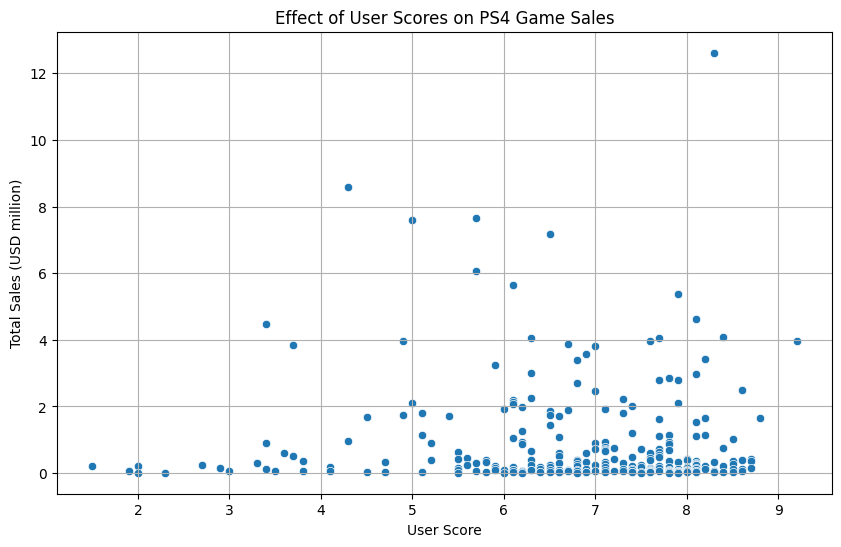

Correlation Coefficient: -0.031957110204556424


In [31]:
# Filter dataset just for PS4 and drop missing values
ps4_user_score = modern_game_data[(modern_game_data['platform'] == 'PS4') & (modern_game_data['user_score'].notna())]

# Create scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=ps4_user_score, x='user_score', y='total_sales')
# Add labels and title
plt.xlabel('User Score')
plt.ylabel('Total Sales (USD million)')
plt.title('Effect of User Scores on PS4 Game Sales')
# Show scatterplot
plt.grid(True)
plt.show()

# Print Pearson correlation coefficient
print("Correlation Coefficient:", ps4_user_score['user_score'].corr(ps4_user_score['total_sales']))

Though this plot does show that the top selling game had a fairly high user score, overall the correlation is very weak. Plenty of games that users love don't have great sales numbers, and plenty that they rated poorly are bringing in a lot of profit. Three of the four top selling games had mediocre scores between 4 and 6!

Let's look at whether critic scores have more of an influence.

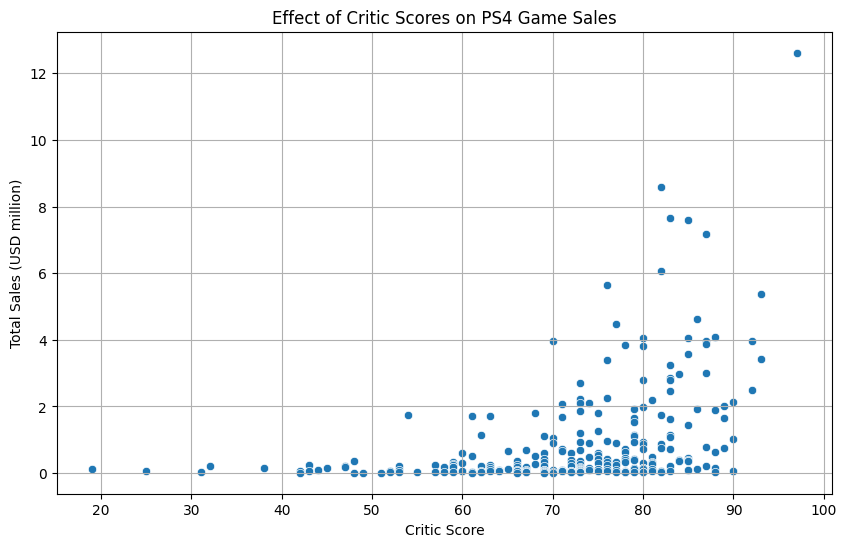

Correlation Coefficient: 0.40656790206178095


In [32]:
# Filter dataset just for PS4 and drop missing values
ps4_critic_score = modern_game_data[(modern_game_data['platform'] == 'PS4') & (modern_game_data['critic_score'].notna())]

# Create scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=ps4_critic_score, x='critic_score', y='total_sales')
# Add labels and title
plt.xlabel('Critic Score')
plt.ylabel('Total Sales (USD million)')
plt.title('Effect of Critic Scores on PS4 Game Sales')
# Show scatterplot
plt.grid(True)
plt.show()

# Print Pearson correlation coefficient
print("Correlation Coefficient:", ps4_critic_score['critic_score'].corr(ps4_critic_score['total_sales']))

The critic score seems to have a bit more influence than the user score, showing a moderate positive correlation that indicates a higher critic score might translate to higher sales, though this won't always be perfectly predictable. 

One explanation for the stronger correlation could be that critic scores are an average of a smaller set of individual critic assessments, while user scores are the average of a much wider range of user opinions. Critic scores also likely come out first and influence the first wave of purchases, while user scores trickle in later and often after many purchase decisions have already been made.

Now, we compare the sales of the same games across platforms. We'll look at three platforms: PS4, 3DS, and XOne.

,name,total_sales_ps4,total_sales_3ds,total_sales_xone
0,FIFA 15,6.08,0.46,2.18
1,FIFA 14,3.01,0.23,1.16
2,LEGO Marvel Super Heroes,1.62,0.89,1.05
3,Lego Batman 3: Beyond Gotham,0.92,0.45,0.44
4,LEGO Jurassic World,0.90,0.62,0.66
5,LEGO Marvel's Avengers,0.73,0.18,0.34
6,Lego Star Wars: The Force Awakens,0.71,0.13,0.29
7,The LEGO Movie Videogame,0.67,0.69,0.53
8,LEGO The Hobbit,0.60,0.24,0.27
9,The Amazing Spider-Man 2 (2014),0.56,0.07,0.22


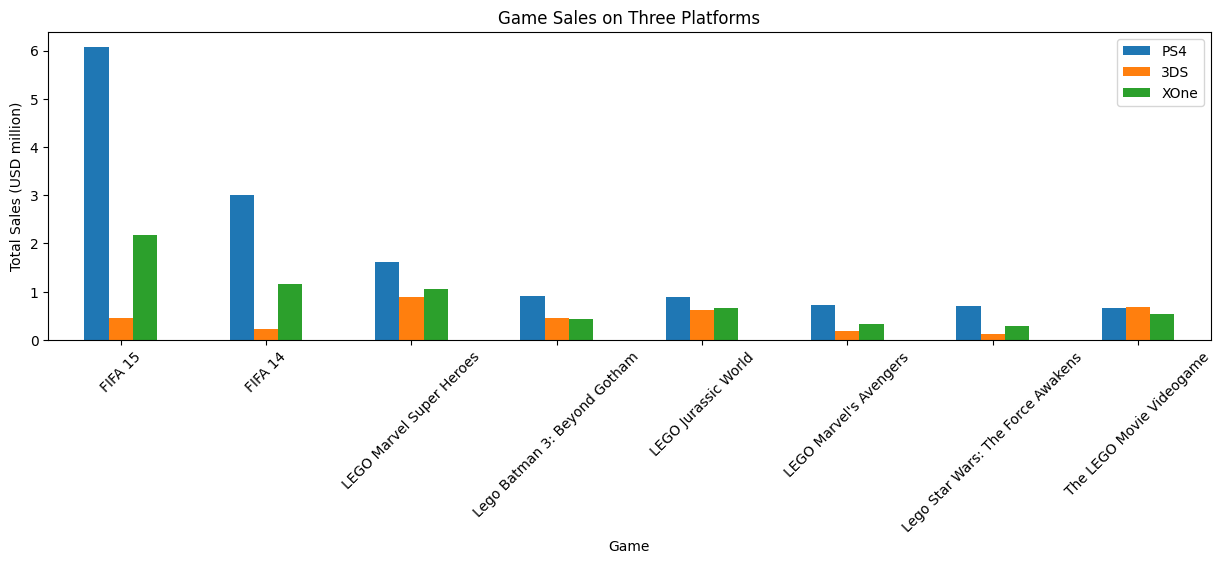

In [33]:
# Create filtered datasets for each platform
sales_ps4 = modern_game_data.query("platform == 'PS4'")[['name','total_sales']]
sales_3ds = modern_game_data.query("platform == '3DS'")[['name','total_sales']]
sales_xone = modern_game_data.query("platform == 'XOne'")[['name','total_sales']]
                              
# Create a merged dataset with only common games                             
sales_ps4_3ds = pd.merge(sales_ps4, sales_3ds, on='name', suffixes=('_ps4','_3ds'))
sales_platform_comparison = pd.merge(sales_ps4_3ds, sales_xone, on='name')
# Rename last column
sales_platform_comparison.rename(columns={'total_sales': 'total_sales_xone'}, inplace=True)
# Display result
display(sales_platform_comparison)

# Visualize results for top 8 games
sales_platform_comparison=sales_platform_comparison.head(8)
platform_comparison_plot=sales_platform_comparison.plot(kind='bar', x='name', y=['total_sales_ps4','total_sales_3ds','total_sales_xone'], xlabel='Game', ylabel='Total Sales (USD million)', title='Game Sales on Three Platforms', figsize=(15,4))
# Relabel legend
platform_comparison_plot.legend(['PS4', '3DS', 'XOne'])
# Rotate game names for readability
plt.xticks(rotation=45) 
plt.show()

It looks like PS4 versions of games tend to make the most sales, followed by XOne versions. The PS4 versions of FIFA 14 and 15 did particularly well compared to their 3DS and XOne counterparts.

Finally, we look at the general distribution of game sales by genre. 

,genre,total_sales
0,Action,323.97
1,Adventure,23.65
2,Fighting,35.31
3,Misc,63.22
4,Platform,42.63
5,Puzzle,3.32
6,Racing,40.08
7,Role-Playing,146.24
8,Shooter,233.16
9,Simulation,22.19


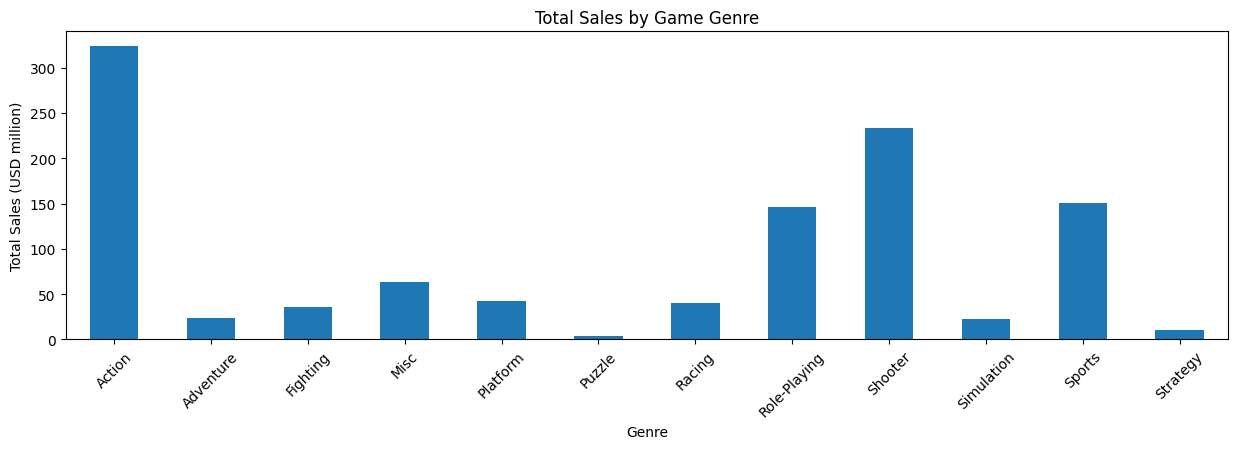

In [34]:
# Create a dataframe showing total sales for each genre
genre_sales=modern_game_data.groupby('genre')['total_sales'].sum().reset_index(name='total_sales')
# Display result
display(genre_sales)

# Visualize distribution
genre_sales_plot=genre_sales.plot(kind='bar', x='genre', y='total_sales', xlabel='Genre', ylabel='Total Sales (USD million)', title='Total Sales by Game Genre', figsize=(15,4), legend=False)

# Rotate genre names for readability
plt.xticks(rotation=45) 
plt.show()

,genre,median_sales
0,Action,0.110
1,Adventure,0.030
2,Fighting,0.125
3,Misc,0.090
4,Platform,0.225
5,Puzzle,0.065
6,Racing,0.120
7,Role-Playing,0.120
8,Shooter,0.445
9,Simulation,0.100


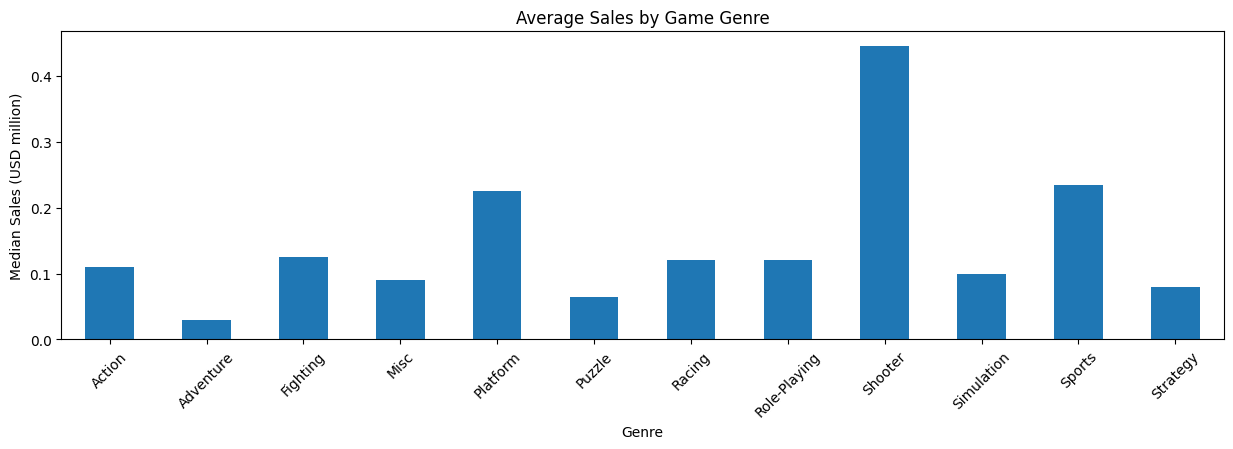

In [35]:
# Create a dataframe showing average sales for each genre
avg_genre_sales=modern_game_data.groupby('genre')['total_sales'].median().reset_index(name='median_sales')
# Display result
display(avg_genre_sales)

# Visualize distribution
avg_genre_sales_plot=avg_genre_sales.plot(kind='bar', x='genre', y='median_sales', xlabel='Genre', ylabel='Median Sales (USD million)', title='Average Sales by Game Genre', figsize=(15,4), legend=False)

# Rotate genre names for readability
plt.xticks(rotation=45) 
plt.show()

When looking at total sales, action seems to be the most profitable genre, followed by shooter, sports, and role-playing games. However, shooter games have the highest median sales, followed by sports. Action games might have higher upside, while shooter and sports games have reliably high sales. The platform category has a bit less certainty, as this could just be a placeholder.

## Create a user profile for each region

In this step, we dig into regional sales data. For each region (NA, EU, JP), we determine the top five platforms and genres in each region, comparing their market shares to highlight regional preferences and industry trends. Additionally, we examine whether ESRB ratings influence sales performance within each region, offering insight into how content ratings may impact consumer behavior in different markets.

First, we'll look at the top five platforms in each region.

In [36]:
# Create dataframe showing sales by platform for Japan
platform_sales_jp = modern_game_data.groupby('platform')['jp_sales'].sum().reset_index(name='jp_sales')
# Sort for top sellers
platform_sales_jp = platform_sales_jp.sort_values(by='jp_sales', ascending=False)
platform_sales_jp = platform_sales_jp.head()
# Print top 5
print ('Top 5 Platforms: Japan')
print(platform_sales_jp)
print()

# Create dataframe showing sales by platform for North America
platform_sales_na = modern_game_data.groupby('platform')['na_sales'].sum().reset_index(name='na_sales')
# Sort for top sellers
platform_sales_na = platform_sales_na.sort_values(by='na_sales', ascending=False)
platform_sales_na = platform_sales_na.head()
# Print top 5
print ('Top 5 Platforms: North America')
print(platform_sales_na)
print()

# Create dataframe showing sales by platform for Europe
platform_sales_eu = modern_game_data.groupby('platform')['eu_sales'].sum().reset_index(name='eu_sales')
# Sort for top sellers
platform_sales_eu = platform_sales_eu.sort_values(by='eu_sales', ascending=False)
platform_sales_eu = platform_sales_eu.head()
# Print top 5
print ('Top 5 Platforms: Europe')
print(platform_sales_eu)


Top 5 Platforms: Japan
  platform  jp_sales
0      3DS     67.86
3      PS3     24.05
6      PSV     18.66
4      PS4     15.96
8     WiiU     10.88

Top 5 Platforms: North America
   platform  na_sales
4       PS4    108.74
10     XOne     93.12
9      X360     82.78
3       PS3     64.04
0       3DS     38.38

Top 5 Platforms: Europe
   platform  eu_sales
4       PS4    141.09
3       PS3     68.11
10     XOne     51.59
9      X360     42.91
0       3DS     30.96


From 2013-2016, PS4, PS3, and 3DS have been top sellers in all three regions. However, XOne and X60 have led more in Europe and North America than in Japan, while Japan has favored 3DS the most.

This data shows that handheld consoles dominated in Japan, which could be due to lifestyle or commuting preferences. Home consoles were more popular in North America and Europe.

Now, we'll look at variations in top genres.

In [37]:
# Create dataframe showing sales by genre for Japan
genre_sales_jp = modern_game_data.groupby('genre')['jp_sales'].sum().reset_index(name='jp_sales')
# Sort for top sellers
genre_sales_jp = genre_sales_jp.sort_values(by='jp_sales', ascending=False)
genre_sales_jp = genre_sales_jp.head()
# Print top 5
print ('Top 5 Genres: Japan')
print(genre_sales_jp)
print()

# Create dataframe showing sales by genre for North America
genre_sales_na = modern_game_data.groupby('genre')['na_sales'].sum().reset_index(name='na_sales')
# Sort for top sellers
genre_sales_na = genre_sales_na.sort_values(by='na_sales', ascending=False)
genre_sales_na = genre_sales_na.head()
# Print top 5
print ('Top 5 Genres: North America')
print(genre_sales_na)
print()

# Create dataframe showing sales by genre for Europe
genre_sales_eu = modern_game_data.groupby('genre')['eu_sales'].sum().reset_index(name='eu_sales')
# Sort for top sellers
genre_sales_eu = genre_sales_eu.sort_values(by='eu_sales', ascending=False)
genre_sales_eu = genre_sales_eu.head()
# Print top 5
print ('Top 5 Genres: Europe')
print(genre_sales_eu)

Top 5 Genres: Japan
          genre  jp_sales
7  Role-Playing     51.20
0        Action     41.20
3          Misc      9.21
2      Fighting      7.65
8       Shooter      6.65

Top 5 Genres: North America
           genre  na_sales
0         Action    126.77
8        Shooter    109.87
10        Sports     65.27
7   Role-Playing     46.51
3           Misc     27.81

Top 5 Genres: Europe
           genre  eu_sales
0         Action    118.64
8        Shooter     87.86
10        Sports     60.53
7   Role-Playing     37.02
6         Racing     20.33


This analysis reveals that Japan heavily favors role-playing games. In contrast, North America and Europe strongly prefer action, shooter, and sports games.

Action games seem globally popular, making them a reliable choice for broad audiences. The fact that shooter games rank #2 in both North America and Europe but #5 in Japan also highlights  cultural preference gap, with Japanese players less inclined to enjoy more violent games.

Finally, we'll look at whether ESRB ratings affect sales in different regions. To do this, we'll convert the categorical ESRB ratings to numeric scores. The five ESRB ratings (E, E10+, T, M, and AO) can be interpreted as a progression of least to most restrictive by age, so we can mirror this with a numeric scale of 1-5 (E=1, E10+=2, T=3, M=4, and AO=5). We'll convert the 'unknown' values to 0. 

In [38]:
# Create filtered datasets for each region that show ratings and region sales
jp_ratings_sales = modern_game_data[['jp_sales', 'rating']].copy()
na_ratings_sales = modern_game_data[['na_sales', 'rating']].copy()
eu_ratings_sales = modern_game_data[['eu_sales', 'rating']].copy()

# Define a dictionary for the numeric ratings
ratings={'unknown': 0, 'E': 1,'E10+': 2,'T': 3,'M': 4,'AO': 5}

# Convert categorical string values in the rating column to integers for each regional dataset
jp_ratings_sales['rating'] = jp_ratings_sales['rating'].map(ratings)
na_ratings_sales['rating'] = na_ratings_sales['rating'].map(ratings)
eu_ratings_sales['rating'] = eu_ratings_sales['rating'].map(ratings)


First, we'll plot the Japan data on a scatterplot.

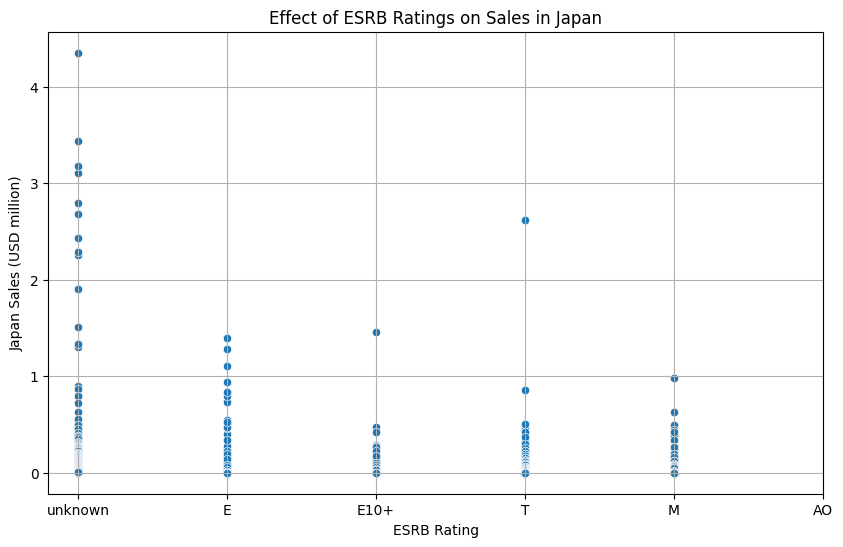

Correlation Coefficient: -0.07414529508837239


In [39]:
# Create Japan scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=jp_ratings_sales, x='rating', y='jp_sales')
# Add labels and title
plt.xlabel('ESRB Rating')
plt.ylabel('Japan Sales (USD million)')
plt.title('Effect of ESRB Ratings on Sales in Japan')
# Show scatterplot
plt.grid(True)
plt.xticks([0, 1, 2, 3, 4, 5], ['unknown', 'E', 'E10+', 'T', 'M', 'AO'])
plt.show()

# Print Pearson correlation coefficient
print("Correlation Coefficient:", jp_ratings_sales['rating'].corr(jp_ratings_sales['jp_sales']))

This shows a very weak negative correlation, which makes sense considering there is a fairly equal spread of games doing less than $2M in sales regardless of the rating and there are a lot of games with high sales and unknown ratings.

Let's look at the other regions.

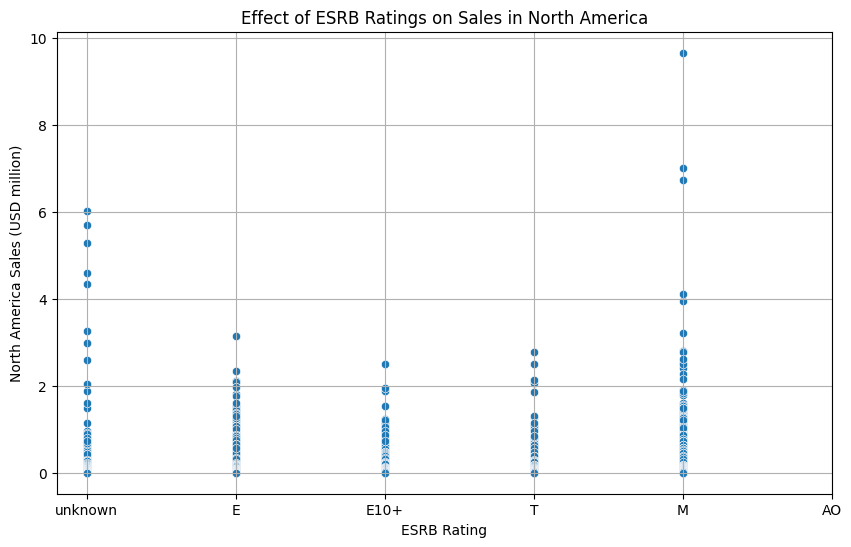

Correlation Coefficient: 0.1869071929944443



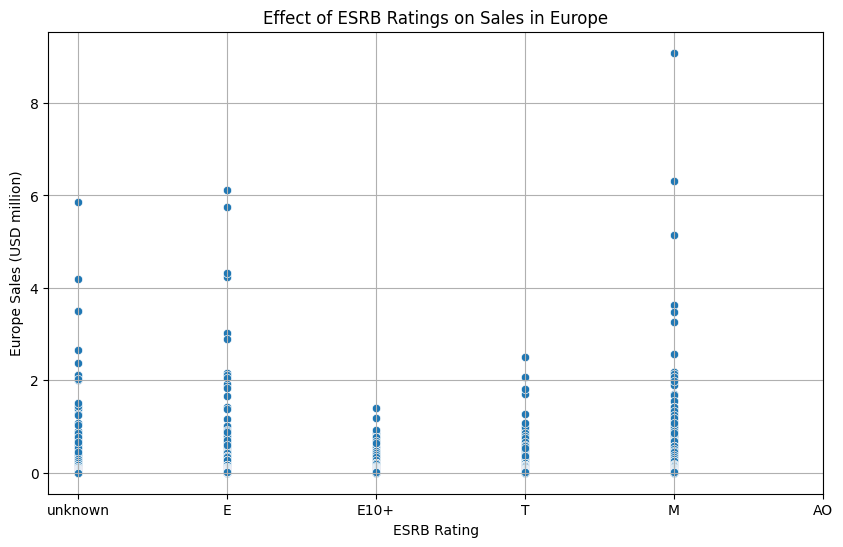

Correlation Coefficient: 0.16782010426712693


In [40]:
# Create North America scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=na_ratings_sales, x='rating', y='na_sales')
# Add labels and title
plt.xlabel('ESRB Rating')
plt.ylabel('North America Sales (USD million)')
plt.title('Effect of ESRB Ratings on Sales in North America')
# Show scatterplot
plt.grid(True)
plt.xticks([0, 1, 2, 3, 4, 5], ['unknown', 'E', 'E10+', 'T', 'M', 'AO'])
plt.show()

# Print Pearson correlation coefficient
print("Correlation Coefficient:", na_ratings_sales['rating'].corr(na_ratings_sales['na_sales']))

print()

# Create Europe scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=eu_ratings_sales, x='rating', y='eu_sales')
# Add labels and title
plt.xlabel('ESRB Rating')
plt.ylabel('Europe Sales (USD million)')
plt.title('Effect of ESRB Ratings on Sales in Europe')
# Show scatterplot
plt.grid(True)
plt.xticks([0, 1, 2, 3, 4, 5], ['unknown', 'E', 'E10+', 'T', 'M', 'AO'])
plt.show()

# Print Pearson correlation coefficient
print("Correlation Coefficient:", eu_ratings_sales['rating'].corr(eu_ratings_sales['eu_sales']))

Interestingly, these other two regions show a slightly positive correlation, though the correlations are still quite weak. Even with the unknown ratings, we can see that the max sales ceiling is  highest for the M category. 

Recalling the results of our genre analysis, this makes sense considering the popularity of shooter games in North America and Europe that tend to have more violent content and require more restrictive ratings. 

Genre information can also help explain the top sellers in Japan.

In [41]:
# Look up the game that did more than $2M in sales in Japan with an E10+ rating
modern_game_data.loc[(modern_game_data['jp_sales'] > 2) & (modern_game_data['rating'] == 'unknown')]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
33,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,unknown,14.60
47,Pokemon Omega Ruby/Pokemon Alpha Sapphire,3DS,2014,Role-Playing,4.35,3.49,3.10,0.74,NaN,NaN,unknown,11.68
96,Super Smash Bros. for Wii U and 3DS,3DS,2014,Fighting,3.27,1.37,2.43,0.48,NaN,NaN,unknown,7.55
108,Pokemon Sun/Moon,3DS,2016,Role-Playing,2.98,1.45,2.26,0.45,NaN,NaN,unknown,7.14
385,Monster Hunter 4,3DS,2013,Role-Playing,0.00,0.00,3.44,0.00,NaN,NaN,unknown,3.44
406,Monster Hunter X,3DS,2015,Action,0.27,0.21,2.79,0.05,NaN,NaN,unknown,3.32
412,Yokai Watch 2 Ganso/Honke,3DS,2014,Role-Playing,0.09,0.00,3.18,0.01,NaN,NaN,unknown,3.28
563,Yokai Watch 2 Shinuchi,3DS,2014,Role-Playing,0.00,0.00,2.68,0.00,NaN,NaN,unknown,2.68
694,Yokai Watch Busters,3DS,2015,Action,0.00,0.00,2.29,0.00,NaN,NaN,unknown,2.29


The mot successful games are largely role-playing games, which we know to be the top selling genre in Japan. 

Overall, it does look like games with more severe ratings have a higher commericial success ceiling in the West than they do in Japan. However, this analysis is based on limited data due the the rating column missing a lot of values, particularly in Japan. 

Furthermore, Europe actually uses the PEGI system for ratings and Japan uses the CERO system, so ESRB ratings can only be interpreted as a proxy in these regions (and this might explain why these regions are missing so much rating data).

## Test the following hypotheses:

In Step 5, we'll test two hypotheses:

* Average user ratings of the Xbox One and PC platforms are the same
* Average user ratings for the Action and Sports genres are different

We'll start with ratings by platform. We formulate the null and alternative hypotheses as follows:

* Null: Average user ratings of the Xbox One and PC platforms are the same
* Alternative: Average user ratings of the Xbox One and PC platforms are different

This is because the alternative hypothesis is the one that proposes a difference. We'll use a two-tailed test, because we're testing for a difference in either direction, and we'll set the alpha threshold at .05 because there's no reason to deviate from the standard.

In [42]:
# Filter modern_game_data to create a dataset for each platform and drop NaN values
xone_scores = modern_game_data[modern_game_data['platform']=='XOne'].dropna(subset=['user_score'])
pc_scores = modern_game_data[modern_game_data['platform']=='PC'].dropna(subset=['user_score'])

# Test the hypotheses

alpha = 0.05  # critical statistical significance level

results = st.ttest_ind(xone_scores['user_score'], pc_scores['user_score'])

# print the p value
print('p-value: ', results.pvalue)

# if the p-value is less than alpha, we reject the hypothesis
if results.pvalue < alpha:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis")

p-value:  0.16390354211387628
We can't reject the null hypothesis


This analysis shows that user scores do not differ significantly between the two platforms (p ≈ 0.164 > α = 0.05), so we cannot reject the null hypothesis.

Now we'll test the hypothesis that average user ratings for the Action and Sports genres are different. We formulate the null and alternative hypotheses as follows:

* Null: Average user ratings of the Action and Sports genres are the same
* Alternative: Average user ratings of the Action and Sports genres are different

Similarly, this is because the alternative hypothesis is the one that proposes a difference. We'll again use a two-tailed test, because we're testing for a difference in either direction, and we'll again set the alpha threshold at .05 because there's no reason to deviate from the standard.

In [43]:
# Filter modern_game_data to create a dataset for each genre and drop NaN values
action_scores = modern_game_data[modern_game_data['genre']=='Action'].dropna(subset=['user_score'])
sports_scores = modern_game_data[modern_game_data['genre']=='Sports'].dropna(subset=['user_score'])

# Test the hypotheses

alpha = 0.05  # critical statistical significance level

results = st.ttest_ind(action_scores['user_score'], sports_scores['user_score'])

# print the p value
print('p-value: ', results.pvalue)

# if the p-value is less than alpha, we reject the hypothesis
if results.pvalue < alpha:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis")

p-value:  4.556444568898562e-28
We reject the null hypothesis


This analysis shows that users scores also differ between the two genres, and the difference is statistically significant.

## Conclusion

This analysis explored global video game sales and user behavior using historical data to inform Ice’s 2017 advertising strategy. After extensive data cleaning and preparation, we examined trends across platforms, genres, regions, and ratings, and tested two hypotheses related to user preferences.

The analysis revealed several insights. First, we learned that platforms tend to follow ~10-year life cycles. Recent top sellers like PS4, 3DS, XOne, and WiiU show  potential for continued performance, while previously strong platforms like PS3, X360, and Wii are declining.

Second, we learned that critic scores showed a moderate positive correlation with game sales, while user scores had little influence. This suggests that early critic reviews may impact buyer behavior more than user feedback. However, this could also be a self-fulfilling prophecy if all retailers tend to market critic favorites more heavily.

In terms of regional preferences, it looks like Japanese customers favor handheld consoles and role-playing games while North Americans and Europeeans lean toward home consoles and action/sports/shooter genres. These preferences suggest cultural differences in gaming habits and content expectations. When looking at ESRB ratings, though they're not directly used in Japan and Europe, the ratings can serve as a  proxy for content maturity. Ratings had little correlation with sales in general, but in Japan, there was a noticeable drop in sales ceiling as ratings grew more restrictive, possibly due to cultural sensitivity or market limitations. Globally, games with the least restrive ratings have the highest potential for commercial success.

Based on our hypothesis testing, user ratings did not differ significantly between Xbox One and PC (we cannot reject the null hypothesis at α = 0.05). However, user ratings did differ significantly between Action and Sports genres. These results suggest that players have clear genre preferences, while Xbox One and PC games receive similar average user scores in this dataset.

Overall, this analysis suggests the following priorities for Ice's 2017 advertising campaigns:

* PS4 and XOne games in North America and Europe, as these are the top-selling platforms in recent years and still shows future promise.
* 3DS games in Japan, where handheld consoles lead.
* Move ad budget away from declining legacy platforms like X360, PS3, Wii, and DS.
* Action games globally, and action, sports, and shooter games in the West as these genres are top sellers and show commerical potential. In Japan, Ice should focus on highlighting role-playing games, even above action and sports.
* Focus on promoting games with less restrictive ratings in mass-market campaigns, as these have the highest sales ceilings.
* Use critic reviews as a starting point for early marketing campaigns by promoting highly-rated games, but contonue to track sales numbers over time and adjust accordingly.

